# 3. CFReT on/off morphologial signature significance plot

This notebook visualizes the statistical significance and effect size of features identified in the CFReT analysis. We create comparative visualizations to assess which morphological features show significant differences between healthy and failing CF cells.

In [1]:
suppressPackageStartupMessages({library(arrow)
library(dplyr)
library(ggplot2)
library(tidyr)
library(viridis)
library(RColorBrewer)
library(patchwork) 
library(IRdisplay)})


setting input and output paths

In [2]:
# setting signature stats path
signatures_stats_path <- file.path("../results/signatures/signature_importance.csv")
if (!file.exists(signatures_stats_path)) {
  stop(paste("File not found:", signatures_stats_path))
}

# setting output path for the generated plot
sig_plot_output_dir = file.path("./figures")
if (!file.exists(sig_plot_output_dir)) {
  stop(paste("File not found:", signatures_stats_path))
} 

loading data

In [3]:
# load feature space config signatures_stats
sig_stats_df <- read.csv(signatures_stats_path)
head(sig_stats_df)

,feature,p_value,ks_stat,p_value_fdr_corrected,neg_log10_p_value,signature,channel
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1,Cytoplasm_AreaShape_BoundingBoxMinimum_X,1.281552e-04,0.06355500,1.495524e-04,3.8252067,on,Cytoplasm
2,Cytoplasm_AreaShape_Compactness,7.846663e-01,0.01883572,7.894728e-01,0.1026628,off,Cytoplasm
3,Cytoplasm_AreaShape_Eccentricity,3.889191e-47,0.21161789,9.903871e-47,46.0041950,on,Cytoplasm
4,Cytoplasm_AreaShape_Extent,1.873207e-21,0.14228771,3.139533e-21,20.5031349,on,Cytoplasm
5,Cytoplasm_AreaShape_FormFactor,7.846663e-01,0.01883572,7.894728e-01,0.1026628,off,Cytoplasm
6,Cytoplasm_AreaShape_MajorAxisLength,7.015711e-42,0.19945032,1.652087e-41,40.7819672,on,Cytoplasm


We generate two side-by-side plots to visualize feature significance:

- **X-axis:** KS statistic (D-statistic) - measures the effect size between healthy and failing CF cell distributions
- **Y-axis:** -log10(FDR-corrected p-value) - measures statistical significance
- **Significance threshold:** Horizontal dashed line at -log10(0.05) indicates the FDR-corrected significance cutoff

**Plot 1 - Feature significance by channel:**  
Colors each feature by its imaging channel (DNA, ER, RNA, AGP, Mito) to identify which channels contribute most to distinguishing healthy from failing cells.

**Plot 2 - Feature significance by signature status:**  
Colors features by their classification as "on" (significant) or "off" (non-significant) signatures, highlighting which features pass the significance threshold.

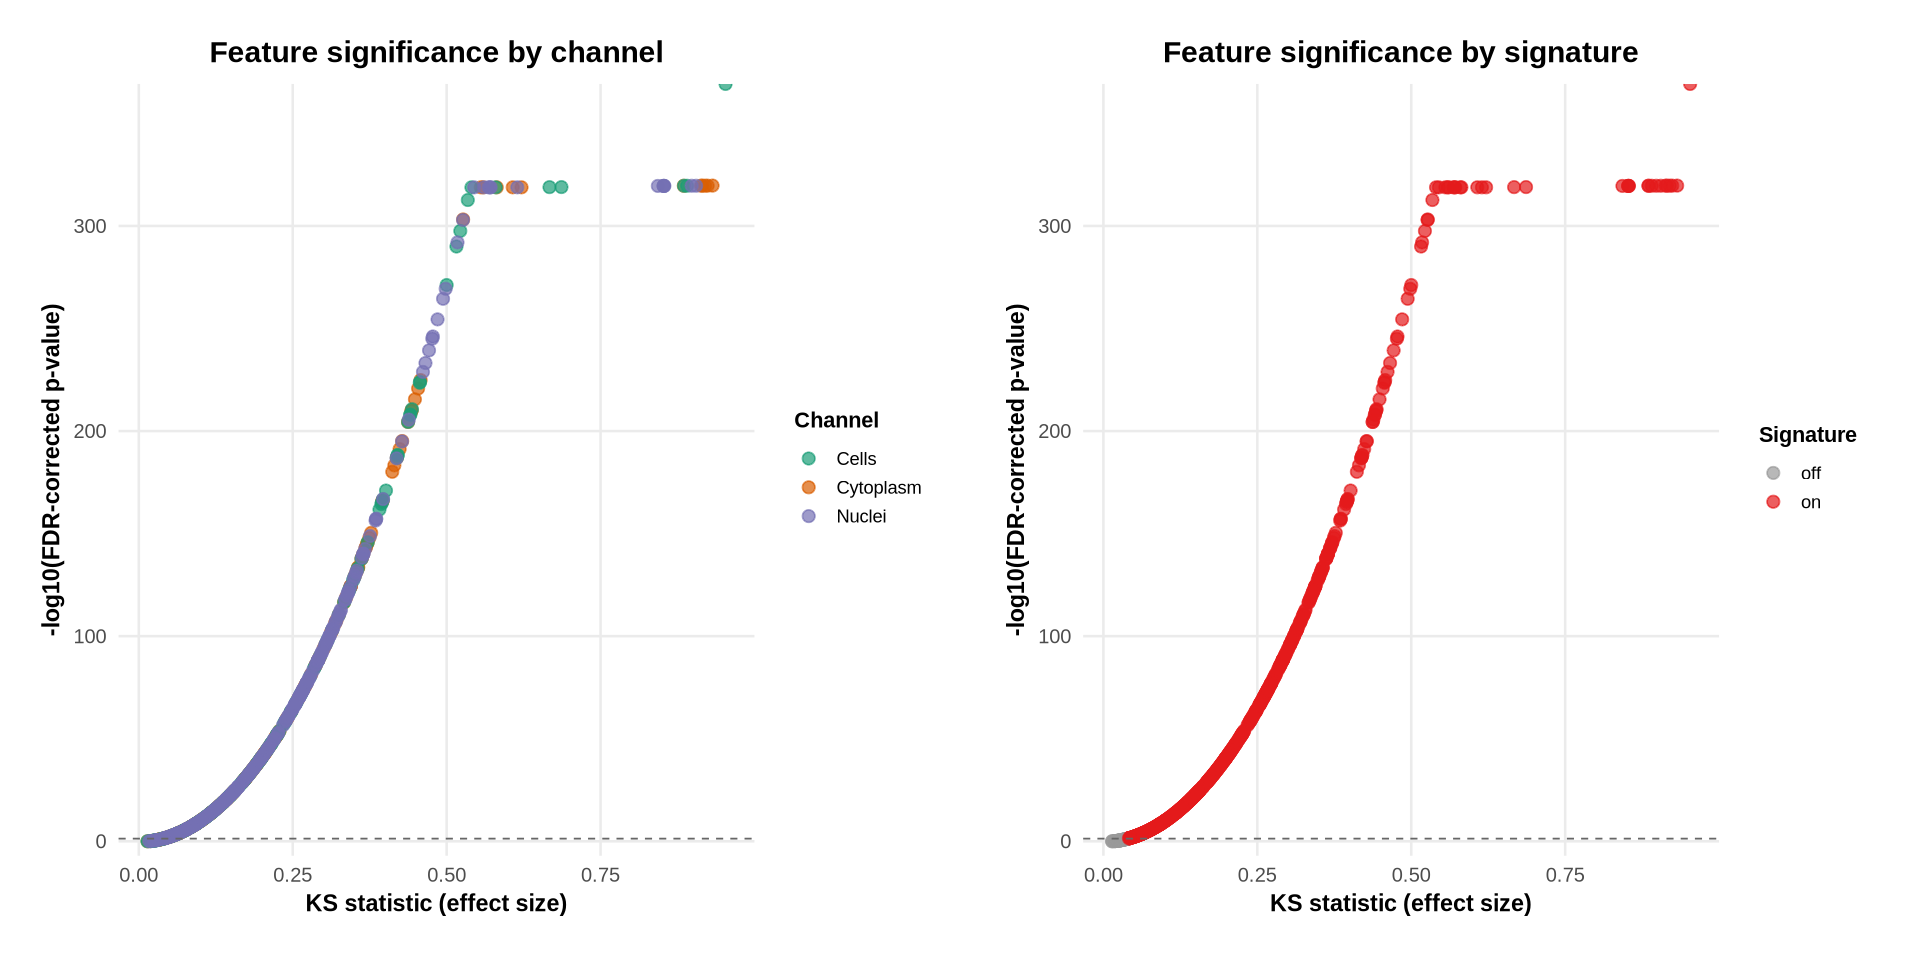

In [4]:

# Render figure size larger
height <- 8
width <- 16  # Increased for two plots side by side
options(repr.plot.width = width, repr.plot.height = height)

# Extract channel from feature names
sig_stats_df$channel <- sapply(strsplit(sig_stats_df$feature, "_"), `[`, 1)

# Set up color palettes
n_channels <- length(unique(sig_stats_df$channel))
dark2_palette <- brewer.pal(min(n_channels, 8), "Dark2")

# Define y-axis limits (extend beyond max to give more space, excluding infinite values)
y_max <- max(sig_stats_df$neg_log10_p_value[is.finite(sig_stats_df$neg_log10_p_value)], na.rm = TRUE) * 1.1

# Plot 1: Colored by Channel
plot_channel <- ggplot(sig_stats_df, aes(x = ks_stat, y = neg_log10_p_value, color = channel)) +
  geom_point(size = 3, alpha = 0.7) +
  scale_color_manual(values = dark2_palette) +
  scale_y_continuous(limits = c(0, y_max), expand = expansion(mult = c(0.02, 0.05))) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40", linewidth = 0.5) +
  labs(
    x = "KS statistic (effect size)",
    y = "-log10(FDR-corrected p-value)",
    title = "Feature significance by channel",
    color = "Channel"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12),
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 13),
    legend.text = element_text(size = 11),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 20, 20, 20)
  )

# Plot 2: Colored by Significant (on/off)
plot_significant <- ggplot(sig_stats_df, aes(x = ks_stat, y = neg_log10_p_value, color = signature)) +
  geom_point(size = 3, alpha = 0.7) +
  scale_color_manual(
    values = c("off" = "gray60", "on" = "#E41A1C"),  
  ) +
  scale_y_continuous(limits = c(0, y_max), expand = expansion(mult = c(0.02, 0.05))) +
  geom_hline(yintercept = -log10(0.05), linetype = "dashed", color = "gray40", linewidth = 0.5) +
  labs(
    x = "KS statistic (effect size)",
    y = "-log10(FDR-corrected p-value)",
    title = "Feature significance by signature",
    color = "Signature"
  ) +
  theme_minimal(base_size = 16) +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 18),
    axis.title = element_text(size = 14, face = "bold"),
    axis.text = element_text(size = 12),
    legend.position = "right",
    legend.title = element_text(face = "bold", size = 13),
    legend.text = element_text(size = 11),
    panel.grid.minor = element_blank(),
    plot.margin = margin(20, 20, 20, 20)
  )

# Combine plots side by side
combined_plot <- plot_channel + plot_significant

# Save plot
ggsave(file.path(sig_plot_output_dir, "cfret_signature_significance_plots.png"), combined_plot, width = 16, height = 8, dpi = 300)

# Display
combined_plot
